In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
train_path = r"/content/drive/MyDrive/Colab Notebooks/CNN_Image_Clasification/train_data"
val_path   = r"/content/drive/MyDrive/Colab Notebooks/CNN_Image_Clasification/val_data"
test_path  = r"/content/drive/MyDrive/Colab Notebooks/CNN_Image_Clasification/test_data"

In [4]:
IMAGE_SIZE = (128,128)
BATCH_SIZE = 32
EPOCHS = 25

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 20 images belonging to 4 classes.
Found 8 images belonging to 4 classes.
Found 12 images belonging to 4 classes.


In [6]:
print(train_generator.class_indices)

{'Ajith': 0, 'Kamal': 1, 'Rajini': 2, 'Vijay': 3}


In [7]:
model = Sequential()

# Layer 1
model.add(Conv2D(32,(3,3),activation='relu',
                 input_shape=(128,128,3)))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2

model.add(Conv2D(64,(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3

model.add(Conv2D(128,(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 4

model.add(Conv2D(256,(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten

model.add(Flatten())

# Dense Layer

model.add(Dense(256,activation='relu'))

model.add(Dropout(0.5))

# Output Layer

model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,748,996 (10.49 MB)

 Trainable params: 2,748,996 (10.49 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [13]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS

)

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6000 - loss: 0.8380 - val_accuracy: 0.1250 - val_loss: 2.5414
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7000 - loss: 0.7998 - val_accuracy: 0.1250 - val_loss: 2.6104
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8000 - loss: 0.6518 - val_accuracy: 0.0000e+00 - val_loss: 2.8110
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8000 - loss: 0.6101 - val_accuracy: 0.1250 - val_loss: 3.2182
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.7796 - val_accuracy: 0.2500 - val_loss: 3.4004
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7000 - loss: 0.6654 - val_accuracy: 0.1250 - val_loss: 3.2263
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.6978 - val_accuracy: 0.0000e+00 - val_loss: 3.0902
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7000 - loss: 0.7626 - val_accuracy: 0.0000e+00 - val_loss: 3.1381
Epoc

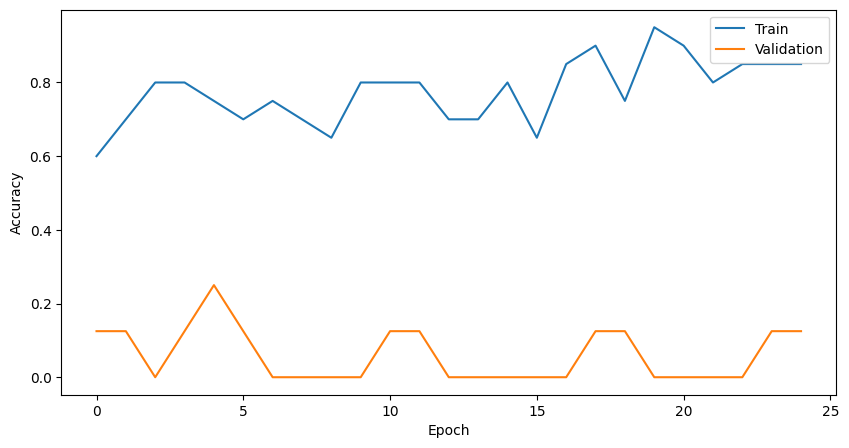

In [14]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

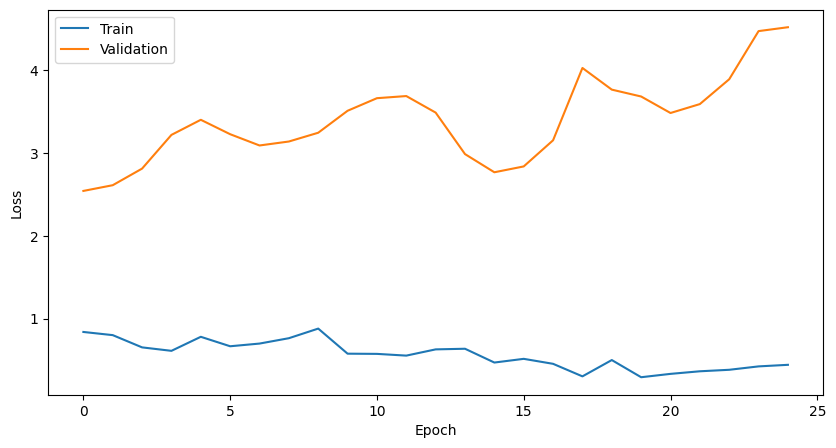

In [15]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [16]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.4167 - loss: 2.3942
Test Loss : 2.3941822052001953
Test Accuracy : 0.4166666567325592


In [17]:
prediction = model.predict(test_generator)

predicted_class = np.argmax(prediction,axis=1)

true_class = test_generator.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step


In [18]:
print(classification_report(
    true_class,
    predicted_class,
    target_names=list(test_generator.class_indices.keys())
))

              precision    recall  f1-score   support

       Ajith       1.00      0.33      0.50         3
       Kamal       0.60      1.00      0.75         3
      Rajini       0.00      0.00      0.00         3
       Vijay       0.25      0.33      0.29         3

    accuracy                           0.42        12
   macro avg       0.46      0.42      0.38        12
weighted avg       0.46      0.42      0.38        12



In [19]:
cm = confusion_matrix(true_class,predicted_class)

print(cm)

[[1 1 1 0]
 [0 3 0 0]
 [0 0 0 3]
 [0 1 1 1]]


In [20]:
model.save("FaceClassifier.keras")

In [25]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the image
img_path = r"/content/drive/MyDrive/Colab Notebooks/CNN_Image_Clasification/train_data/Ajith/A5.jpg"

img = image.load_img(
    img_path,
    target_size=(128, 128)
)

# Convert image to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Get predicted class index
predicted_index = np.argmax(prediction)

# Convert class indices to class names
class_names = {v: k for k, v in train_generator.class_indices.items()}

# Get predicted person name
predicted_person = class_names[predicted_index]

# Prediction confidence
confidence = np.max(prediction) * 100

print(f"Predicted Person : {predicted_person}")
print(f"Confidence       : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Predicted Person : Ajith
Confidence       : 99.98%


In [23]:
train_generator.class_indices.items()

dict_items([('Ajith', 0), ('Kamal', 1), ('Rajini', 2), ('Vijay', 3)])